### Telecom Customer Churn Analytics

## Business Objective
Predict customers likely to churn while uncovering behavioral patterns that help the telecom company reduce revenue loss through targeted retention strategies.

## Data Audit & Business Understanding

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Telecom Churn Rate Dataset.csv to Telecom Churn Rate Dataset.csv


In [ ]:
df = pd.read_csv("Telecom Churn Rate Dataset.csv")

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0,0,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,0,0,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,Yes


In [ ]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
6857,1930-WNXSB,Male,0,Yes,Yes,58,Yes,No,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,92.85,5305.05,0,0,No
5956,3640-PHQXK,Female,0,No,No,31,Yes,Yes,Fiber optic,No,No,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,89.90,2806.9,0,5,Yes
6347,7718-RXDGG,Male,0,Yes,No,15,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),68.60,1108.6,0,0,No
3550,0963-ZBDRN,Male,0,No,No,32,Yes,No,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,96.20,3183.4,1,3,Yes
4328,1101-SSWAG,Female,0,Yes,No,15,Yes,Yes,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,51.10,711.15,0,0,No


In [ ]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,0,0,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,0,5,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,0,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,0,0,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,2,0,No


# Observations

## Customer Ids appear unique.
## The target column is Churn.
## Features contain demographics, security and entertainment services, billing methods, and total charges.

In [ ]:
df.shape

(7043, 23)

The dataset contains customer-level observations, with each row representing one customer and each column representing Customer Identifiers & Demographics, Subscription Profile & Core Services, Internet Add-On Services, Contract, Billing & Financials, Support & Operations, and Target / Outcome Variable.

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'numAdminTickets',
       'numTechTickets', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#Checking for DType
Total charges must not be in object DType

In [ ]:
df["TotalCharges"].head(20)

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
5,820.5
6,1949.4
7,301.9
8,3046.05
9,3487.95


In [ ]:
df["TotalCharges"].unique()[:20]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8',
       '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25',
       '528.35', '1862.9'], dtype=object)

In [ ]:
df[df["TotalCharges"]==" "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,0,0,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,5,0,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,0,0,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,1,0,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,0,0,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,0,0,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,0,0,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,5,0,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,0,0,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,0,0,No


In [ ]:
df["TotalCharges"].dtype

dtype('O')

In [ ]:
df["TotalCharges"].apply(type).value_counts()

,count
TotalCharges,
<class 'str'>,7043


In [ ]:
df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,0,0,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,5,0,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,0,0,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,1,0,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,0,0,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,0,0,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,0,0,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,5,0,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,0,0,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,0,0,No


In [ ]:
df[df["TotalCharges"].str.strip() == ""][["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


In [ ]:
blank_count = (df["TotalCharges"].str.strip() == "").sum()
print(f"Number of blank values: {blank_count}")

Number of blank values: 11


In [ ]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.515689,0.419566
std,0.368612,24.559481,30.090047,2266.794470,1.275299,1.250117
min,0.000000,0.000000,18.250000,0.000000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,0.000000,0.000000
max,1.000000,72.000000,118.750000,8684.800000,5.000000,9.000000


In [ ]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


#Insights based on statistics
## Insight 1
The customer base is highly diverse in terms of total spending, with TotalCharges ranging from 0 to over 8600. This suggests the presence of both newly acquired and long-term, high-value customers.
## Insight 2
The median monthly charge is around 70, indicating that most customers subscribe to mid-priced plans rather than premium offerings.
## Insight 3
Half of the customers have remained with the company for approximately 29 months or longer, suggesting a reasonably loyal customer base alongside newer customers.
## Insight 4
Support ticket variables are heavily right-skewed, with most customers never raising support requests. This warrants further investigation into whether frequent support interactions are associated with churn.
## Insight 5
Only around 16% of customers are senior citizens, indicating that this demographic is a minority within the customer base.

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": round(df.isnull().mean()*100,2)
})

missing.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["customerID"].duplicated().sum()

np.int64(0)

In [ ]:
df.nunique().sort_values()

,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
PhoneService,2
PaperlessBilling,2
Churn,2
MultipleLines,3
TechSupport,3
StreamingTV,3


# Creating Feature Lists

In [ ]:
identifier_col = "customerID"

target_col = "Churn"

binary_cols = [
    "SeniorCitizen"
]

numerical_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "numAdminTickets",
    "numTechTickets"
]

categorical_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [ ]:
print("Identifier Column:")
print(identifier_col)

print("\nTarget Column:")
print(target_col)

print("\nBinary Columns:")
print(binary_cols)

print("\nNumerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Identifier Column:
customerID

Target Column:
Churn

Binary Columns:
['SeniorCitizen']

Numerical Columns:
['tenure', 'MonthlyCharges', 'TotalCharges', 'numAdminTickets', 'numTechTickets']

Categorical Columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Business Hypotheses for Exploratory Data Analysis
| Hypothesis ID | Business Hypothesis                                                                                          | Why it Matters                                                                   |
| ------------- | ------------------------------------------------------------------------------------------------------------ | -------------------------------------------------------------------------------- |
| H1            | Customers with shorter tenure are more likely to churn.                                                      | New customers may not have developed loyalty.                                    |
| H2            | Customers on month-to-month contracts churn more than those on longer contracts.                             | Contract commitment may improve retention.                                       |
| H3            | Customers with higher monthly charges are more likely to churn.                                              | Higher prices may increase price sensitivity.                                    |
| H4            | Customers with more administrative or technical support tickets are more likely to churn.                    | Frequent support interactions may indicate unresolved issues or dissatisfaction. |
| H5            | Customers subscribed to value-added services (e.g., Online Security, Tech Support) are less likely to churn. | Additional services may increase engagement and switching costs.                 |
| H6            | Senior citizens exhibit different churn behavior than non-senior customers.                                  | Different demographics may require different retention strategies.               |


## Exploratory Data Analysis
**Objective**

The objective of this analysis is to understand customer behavior, identify factors associated with churn, validate business hypotheses, and uncover actionable insights that can guide customer retention strategies.

In [ ]:

# EDA HELPER FUNCTIONS

def target_analysis(df, target="Churn"):
    print("\nTARGET VARIABLE ANALYSIS")

    print("\nCount")
    display(df[target].value_counts())

    print("\nPercentage")
    display((df[target].value_counts(normalize=True)*100).round(2))

    plt.figure(figsize=(6,4))
    ax = sns.countplot(data=df, x=target, hue=target, palette="Set2", legend=False)

    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}",
                    (p.get_x()+p.get_width()/2, p.get_height()),
                    ha="center",
                    va="bottom")

    plt.title("Target Distribution")
    plt.show()


def categorical_analysis(df, feature, target="Churn"):

    print(f"\n{feature.upper()}")

    print("\nCount Table")
    display(pd.crosstab(df[feature], df[target], margins=True))

    print("\nChurn Percentage")
    display((pd.crosstab(df[feature], df[target], normalize="index")*100).round(2))

    fig, ax = plt.subplots(1,2, figsize=(14,5))

    sns.countplot(
        data=df,
        x=feature,
        hue=target,
        palette="Set2",
        ax=ax[0]
    )

    ax[0].set_title(f"{feature} vs Churn")

    churn = pd.crosstab(
        df[feature],
        df[target],
        normalize="index"
    )*100

    churn.plot(kind="bar", ax=ax[1])

    ax[1].set_title(f"Churn Rate by {feature}")
    ax[1].set_ylabel("Percentage")

    plt.tight_layout()
    plt.show()


def numerical_analysis(df, feature, target="Churn"):

    print(f"\n{feature.upper()}")

    display(df.groupby(target)[feature].describe())

    fig, ax = plt.subplots(1,2, figsize=(14,5))

    sns.histplot(df[feature], kde=True, ax=ax[0])

    ax[0].set_title(f"Distribution of {feature}")

    sns.boxplot(
        data=df,
        x=target,
        y=feature,
        ax=ax[1]
    )

    ax[1].set_title(f"{feature} vs Churn")

    plt.tight_layout()
    plt.show()


def correlation_analysis(df, numerical_cols):

    plt.figure(figsize=(8,6))

    sns.heatmap(
        df[numerical_cols].corr(),
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title("Correlation Heatmap")

    plt.show()


def support_analysis(df):

    for feature in ["numAdminTickets","numTechTickets"]:

        print(f"\n{feature.upper()}")

        display((pd.crosstab(df[feature],
                             df["Churn"],
                             normalize="index")*100).round(2))

        plt.figure(figsize=(6,4))

        sns.barplot(
            x=df.groupby(feature)["Churn"].apply(lambda x:(x=="Yes").mean()*100).index,
            y=df.groupby(feature)["Churn"].apply(lambda x:(x=="Yes").mean()*100).values
        )

        plt.title(f"Churn Rate vs {feature}")

        plt.ylabel("Churn %")

        plt.show()


def frustration_analysis(df):

    df["CustomerFrustrationIndex"] = (
        df["numAdminTickets"] +
        df["numTechTickets"]
    )

    plt.figure(figsize=(7,4))

    sns.barplot(
        x=df.groupby("CustomerFrustrationIndex")["Churn"].apply(lambda x:(x=="Yes").mean()*100).index,
        y=df.groupby("CustomerFrustrationIndex")["Churn"].apply(lambda x:(x=="Yes").mean()*100).values
    )

    plt.title("Customer Frustration Index vs Churn")

    plt.ylabel("Churn %")

    plt.show()


def interaction_analysis(df, feature1, feature2):

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x=feature1,
        y=feature2,
        hue="Churn"
    )

    plt.title(f"{feature1} vs {feature2}")

    plt.show()

## Section 1: TARGET VARIABLE


TARGET VARIABLE ANALYSIS

Count


,count
Churn,
No,5174
Yes,1869



Percentage


,proportion
Churn,
No,73.46
Yes,26.54


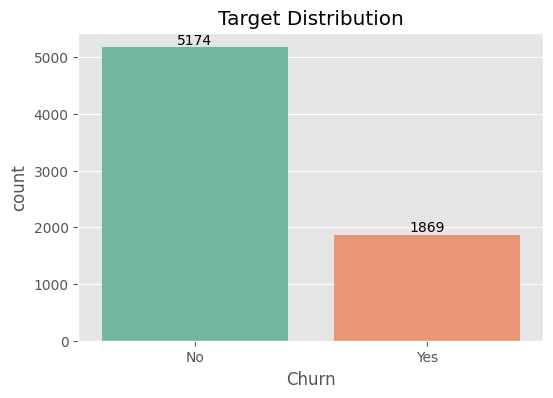

In [ ]:
target_analysis(df)

## Section 2: CUSTOMER DEMOGRAPHICS


SENIORCITIZEN

Count Table


Churn,No,Yes,All
SeniorCitizen,,,
0,4508,1393,5901
1,666,476,1142
All,5174,1869,7043



Churn Percentage


Churn,No,Yes
SeniorCitizen,,
0,76.39,23.61
1,58.32,41.68


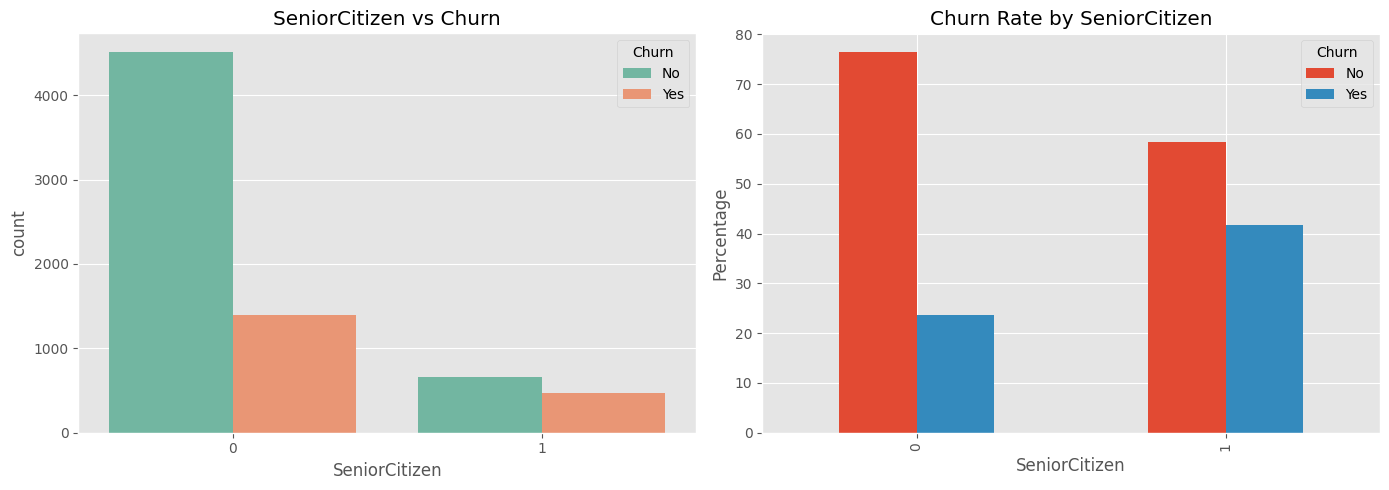


GENDER

Count Table


Churn,No,Yes,All
gender,,,
Female,2549,939,3488
Male,2625,930,3555
All,5174,1869,7043



Churn Percentage


Churn,No,Yes
gender,,
Female,73.08,26.92
Male,73.84,26.16


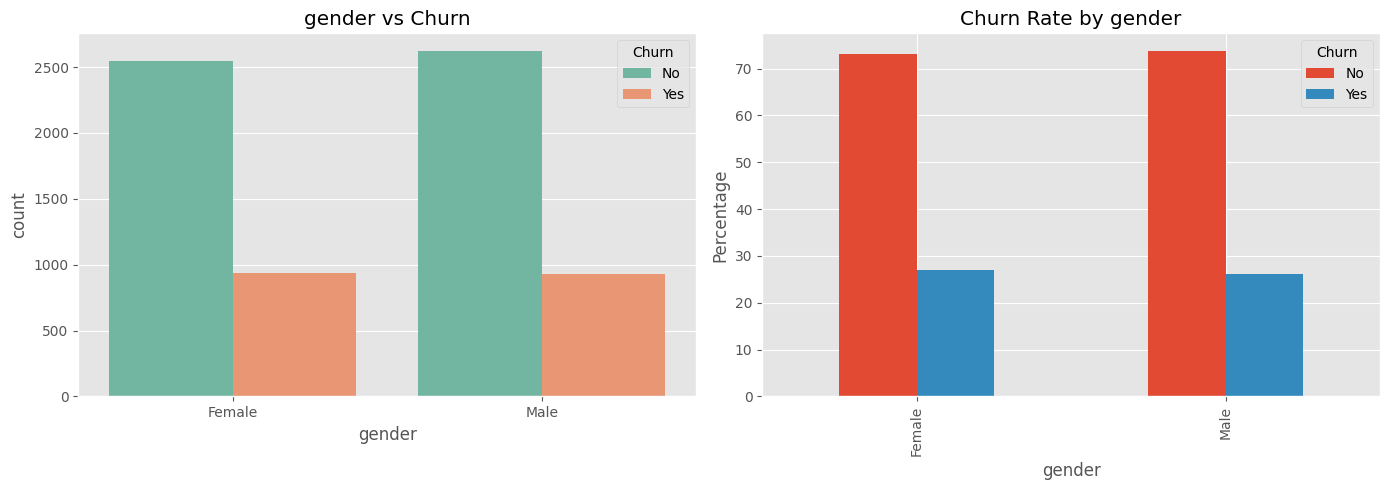


DEPENDENTS

Count Table


Churn,No,Yes,All
Dependents,,,
No,3390,1543,4933
Yes,1784,326,2110
All,5174,1869,7043



Churn Percentage


Churn,No,Yes
Dependents,,
No,68.72,31.28
Yes,84.55,15.45


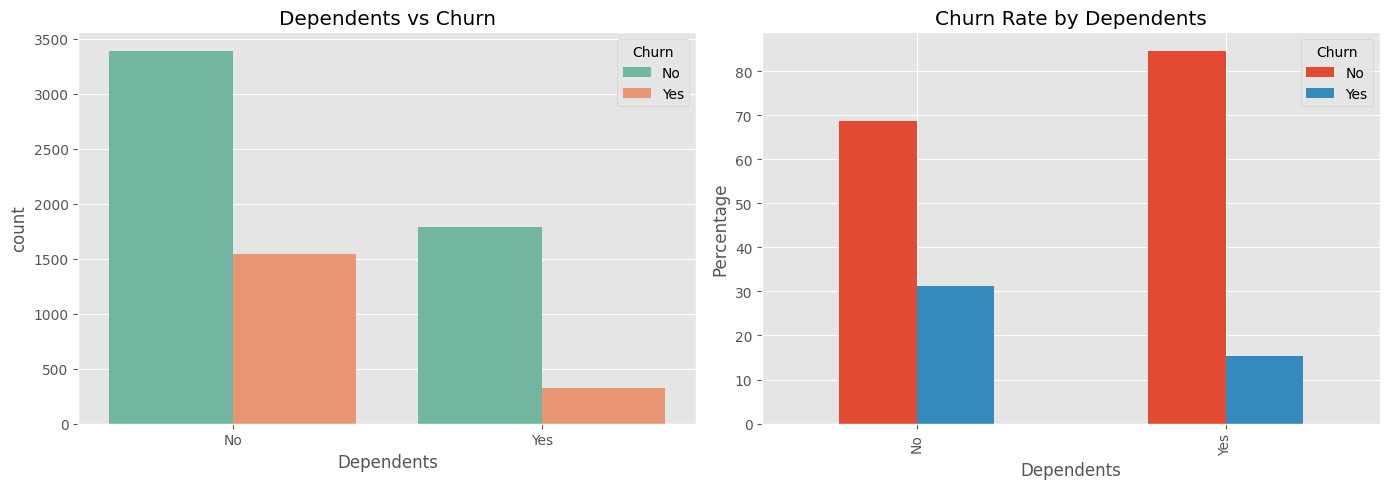


PARTNER

Count Table


Churn,No,Yes,All
Partner,,,
No,2441,1200,3641
Yes,2733,669,3402
All,5174,1869,7043



Churn Percentage


Churn,No,Yes
Partner,,
No,67.04,32.96
Yes,80.34,19.66


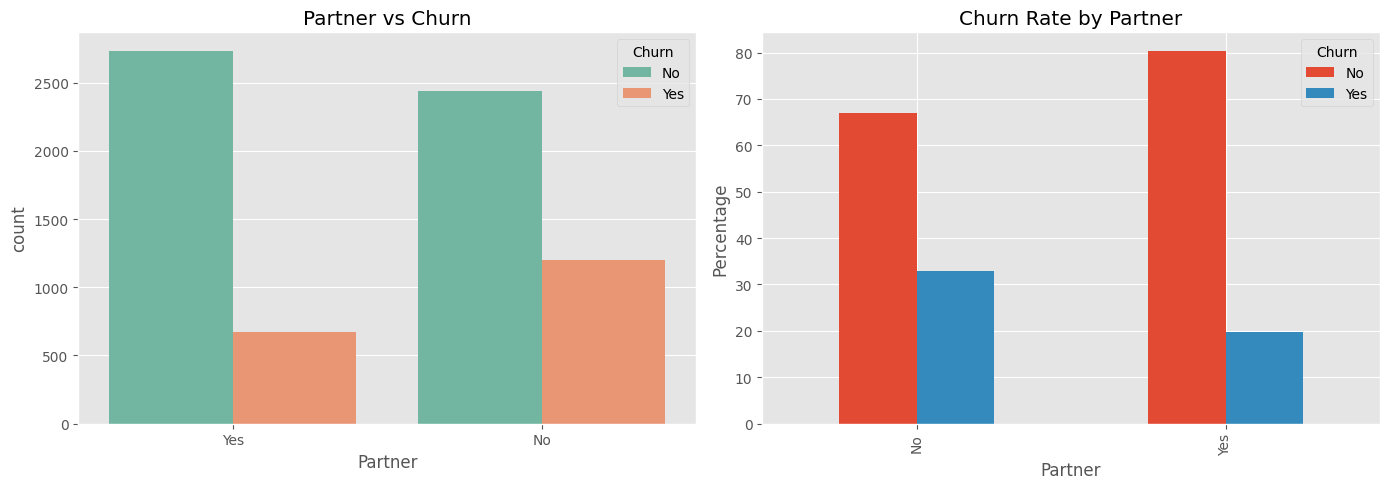

In [ ]:
for feature in ["SeniorCitizen","gender","Dependents","Partner"]:
    categorical_analysis(df, feature)

## Section 3: CUSTOMER LIFETIME


TENURE


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


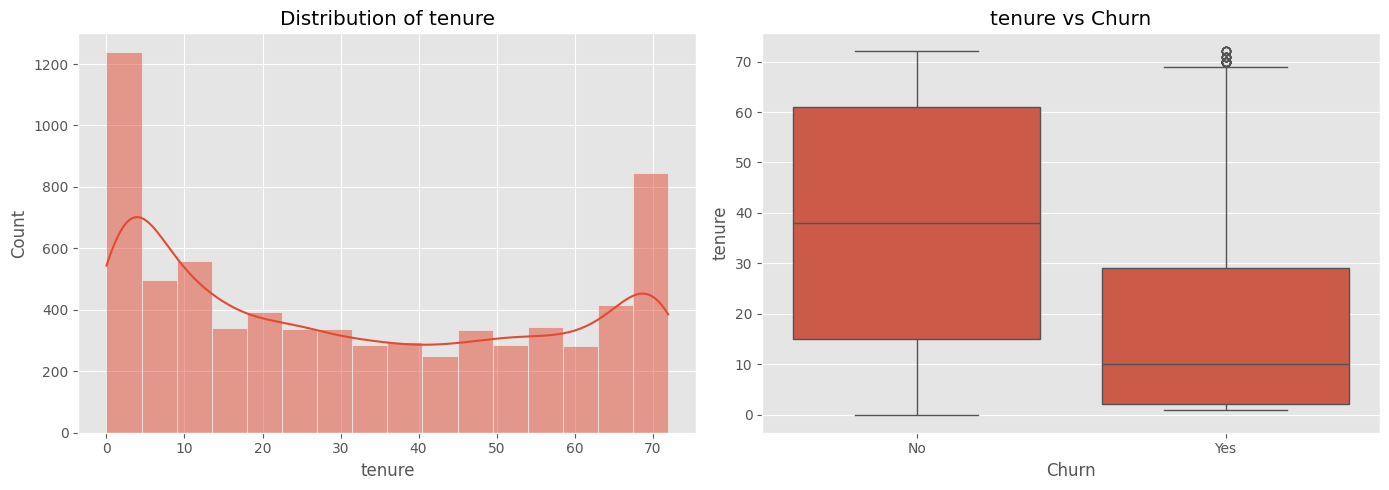

In [ ]:
numerical_analysis(df,"tenure")

## SECTION 4: FINANCIAL BEHAVIOUR


MONTHLYCHARGES


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


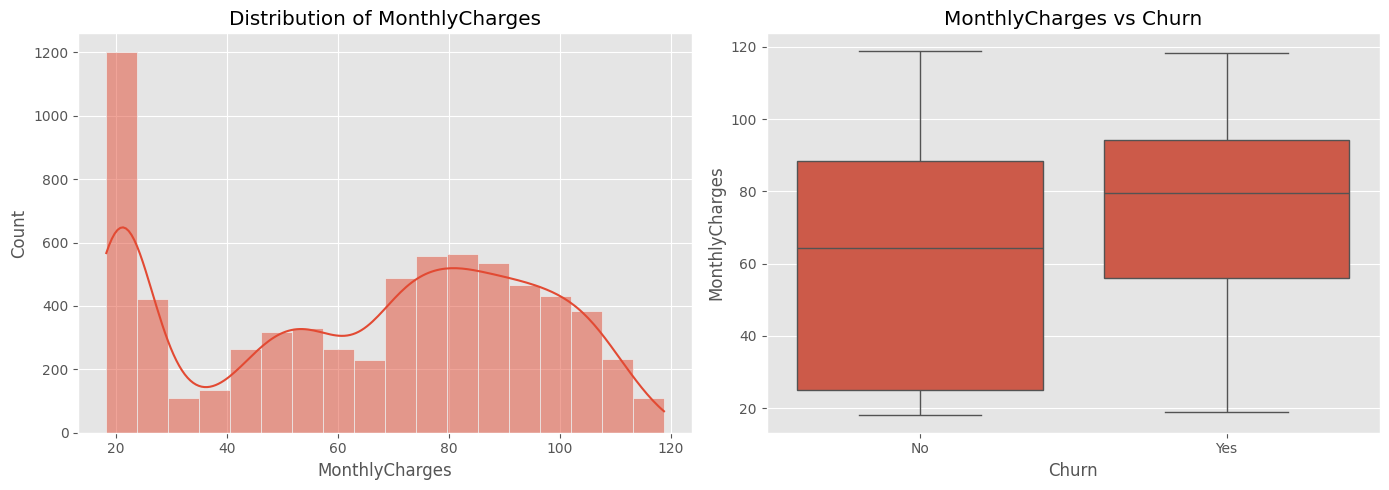


TOTALCHARGES


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


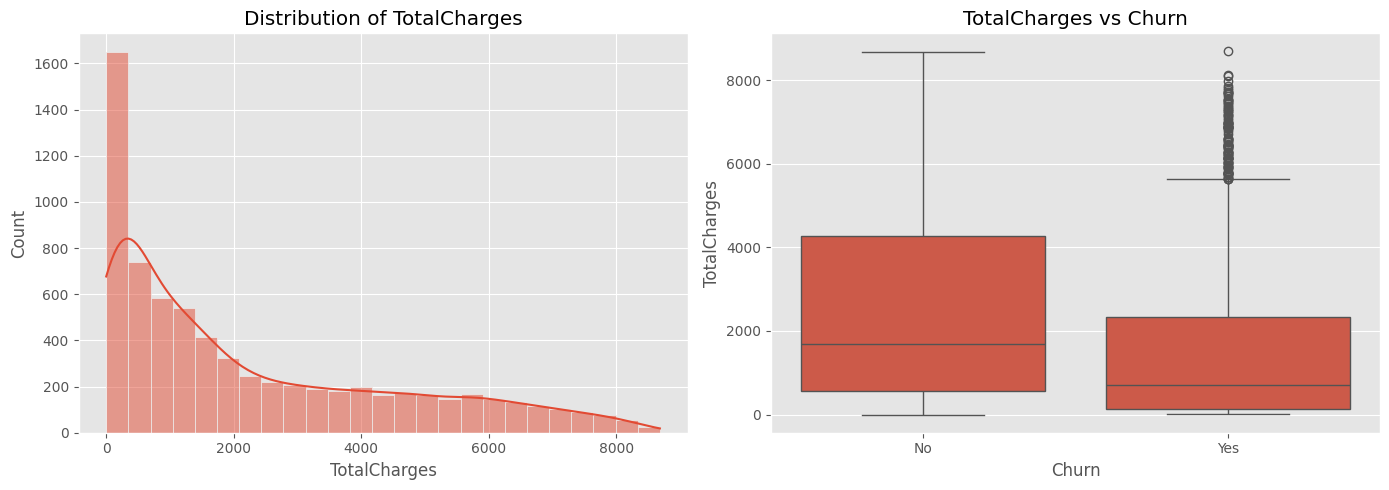

In [ ]:
for feature in ["MonthlyCharges","TotalCharges"]:
    numerical_analysis(df, feature)

## SECTION 5: SERVICES


PHONESERVICE

Count Table


Churn,No,Yes,All
PhoneService,,,
No,512,170,682
Yes,4662,1699,6361
All,5174,1869,7043



Churn Percentage


Churn,No,Yes
PhoneService,,
No,75.07,24.93
Yes,73.29,26.71


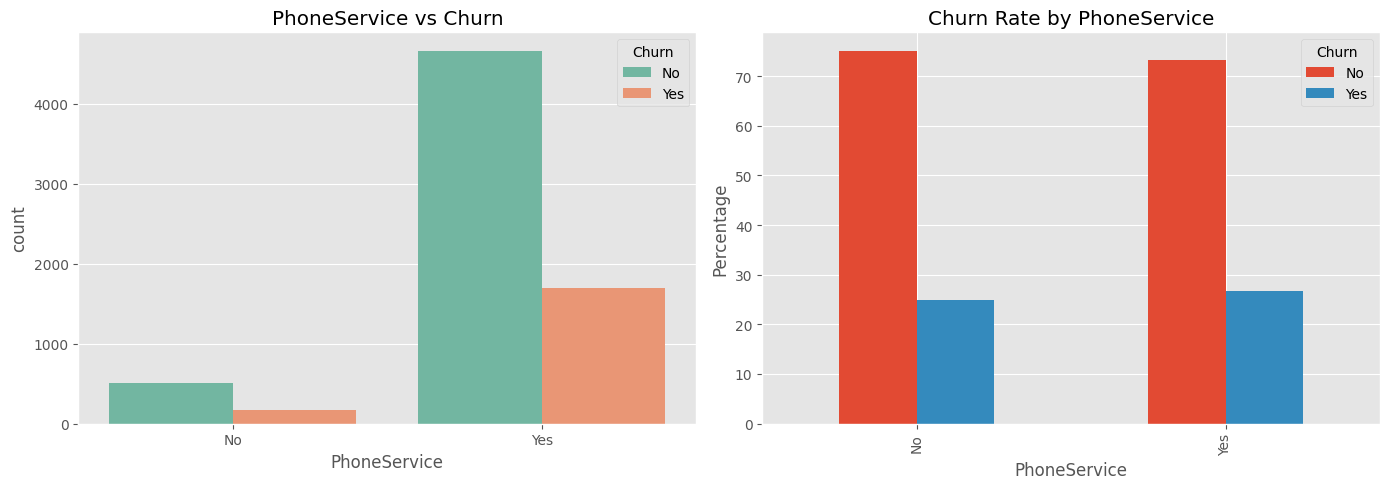


MULTIPLELINES

Count Table


Churn,No,Yes,All
MultipleLines,,,
No,2541,849,3390
No phone service,512,170,682
Yes,2121,850,2971
All,5174,1869,7043



Churn Percentage


Churn,No,Yes
MultipleLines,,
No,74.96,25.04
No phone service,75.07,24.93
Yes,71.39,28.61


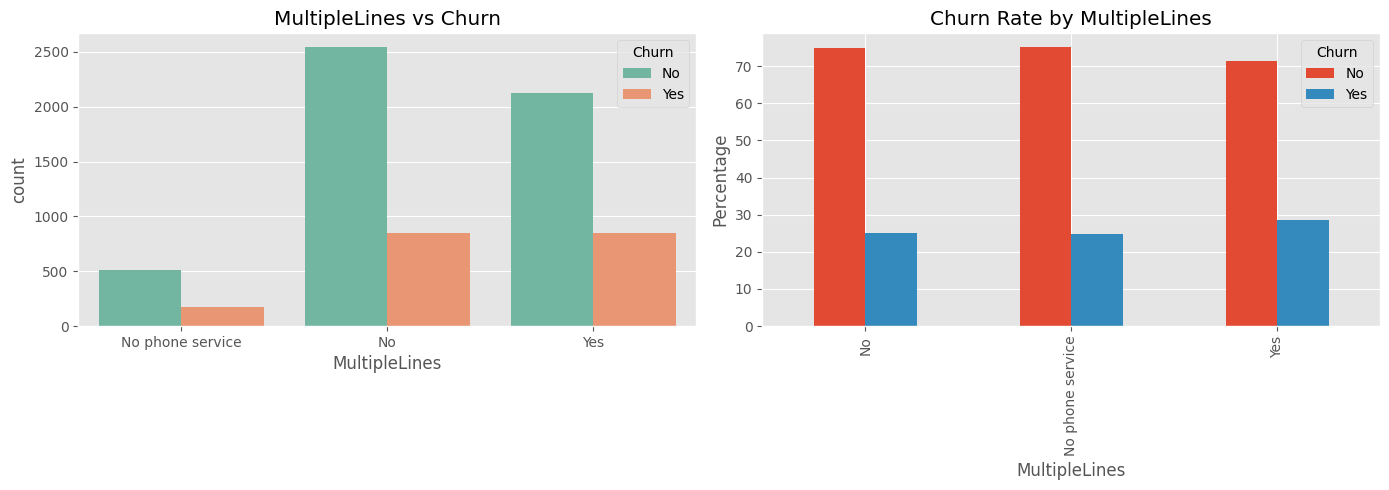


INTERNETSERVICE

Count Table


Churn,No,Yes,All
InternetService,,,
DSL,1962,459,2421
Fiber optic,1799,1297,3096
No,1413,113,1526
All,5174,1869,7043



Churn Percentage


Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


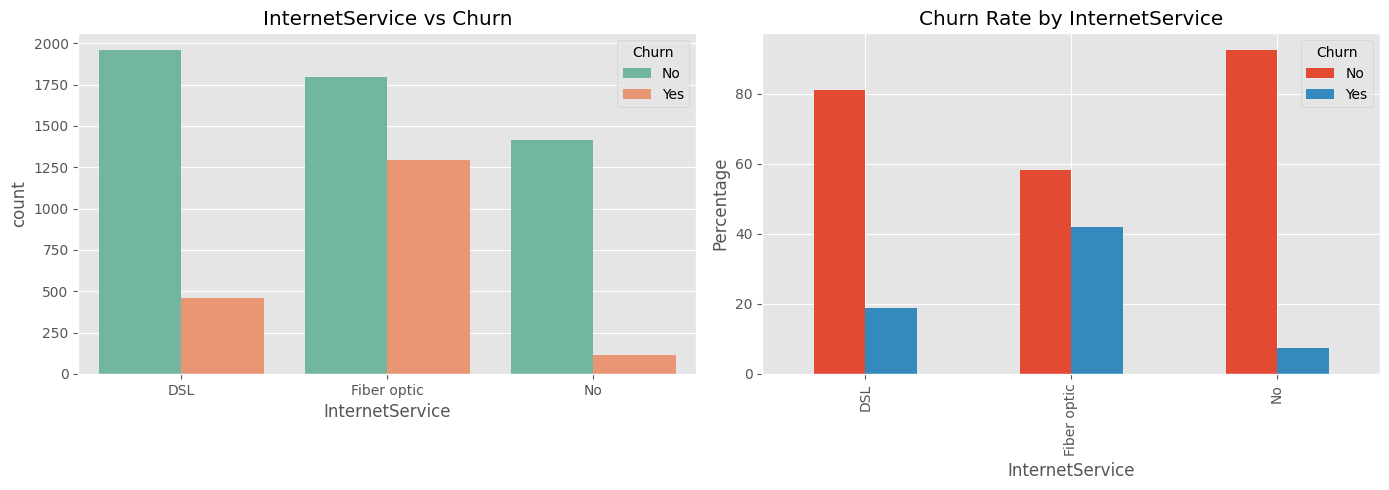


ONLINESECURITY

Count Table


Churn,No,Yes,All
OnlineSecurity,,,
No,2037,1461,3498
No internet service,1413,113,1526
Yes,1724,295,2019
All,5174,1869,7043



Churn Percentage


Churn,No,Yes
OnlineSecurity,,
No,58.23,41.77
No internet service,92.60,7.40
Yes,85.39,14.61


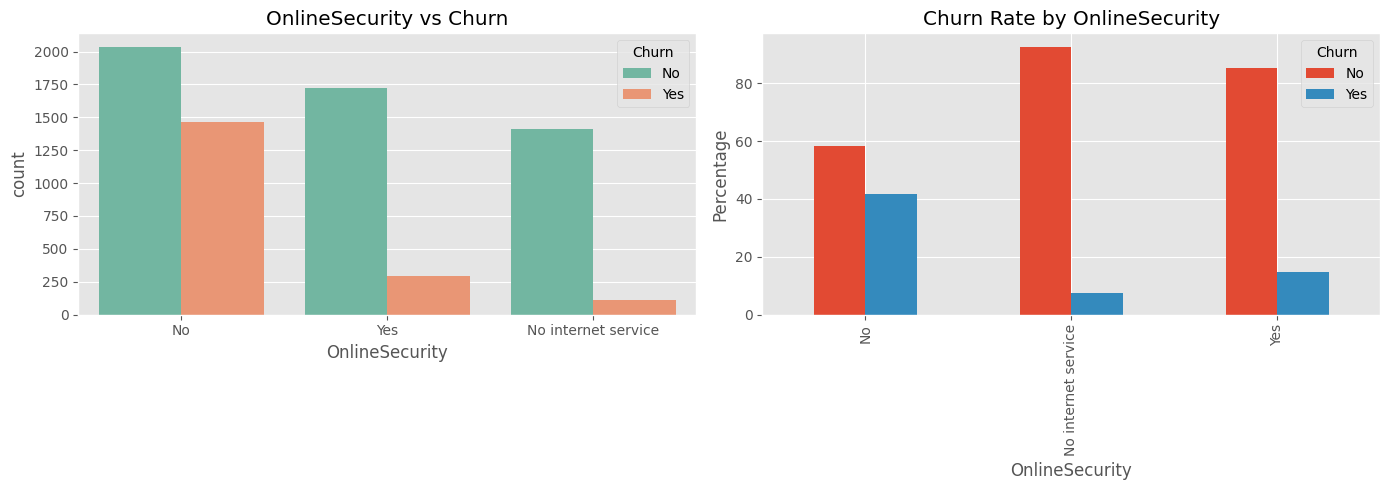


ONLINEBACKUP

Count Table


Churn,No,Yes,All
OnlineBackup,,,
No,1855,1233,3088
No internet service,1413,113,1526
Yes,1906,523,2429
All,5174,1869,7043



Churn Percentage


Churn,No,Yes
OnlineBackup,,
No,60.07,39.93
No internet service,92.60,7.40
Yes,78.47,21.53


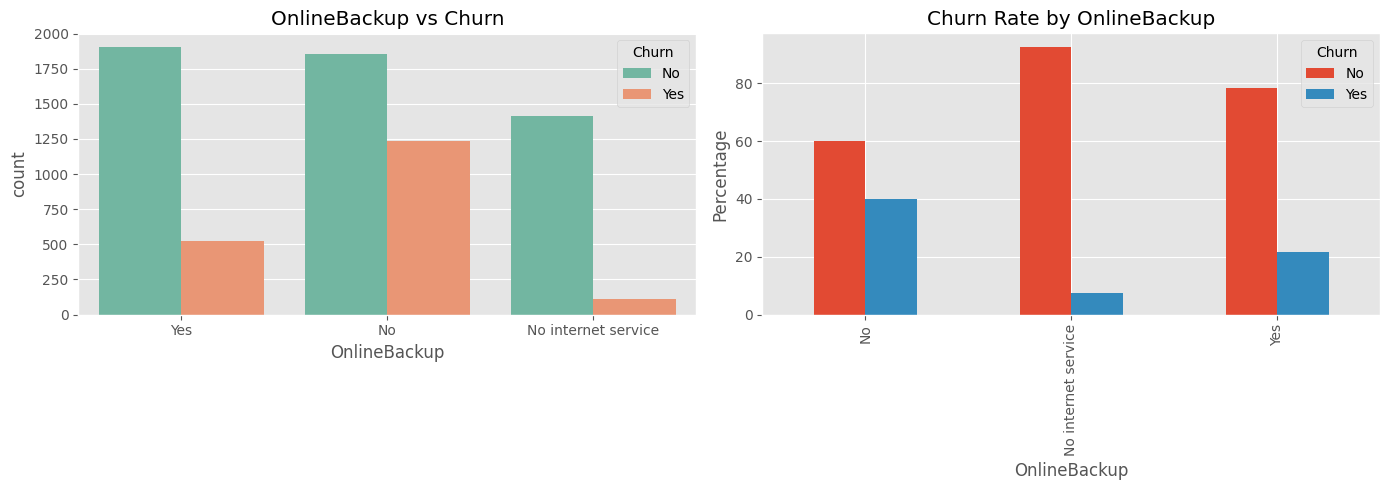


DEVICEPROTECTION

Count Table


Churn,No,Yes,All
DeviceProtection,,,
No,1884,1211,3095
No internet service,1413,113,1526
Yes,1877,545,2422
All,5174,1869,7043



Churn Percentage


Churn,No,Yes
DeviceProtection,,
No,60.87,39.13
No internet service,92.60,7.40
Yes,77.50,22.50


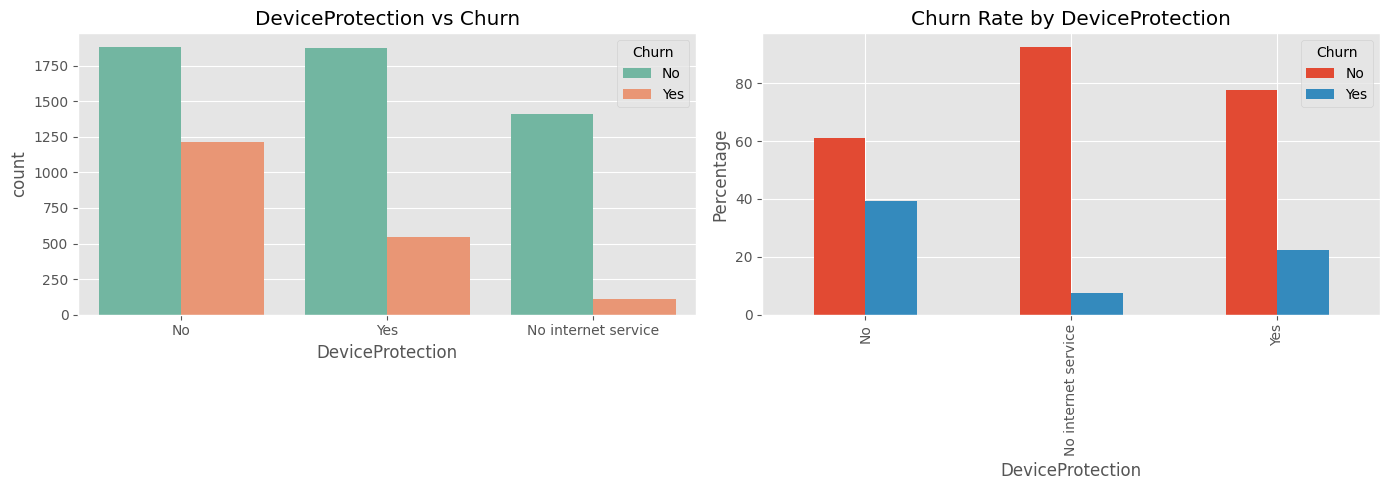


TECHSUPPORT

Count Table


Churn,No,Yes,All
TechSupport,,,
No,2027,1446,3473
No internet service,1413,113,1526
Yes,1734,310,2044
All,5174,1869,7043



Churn Percentage


Churn,No,Yes
TechSupport,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17


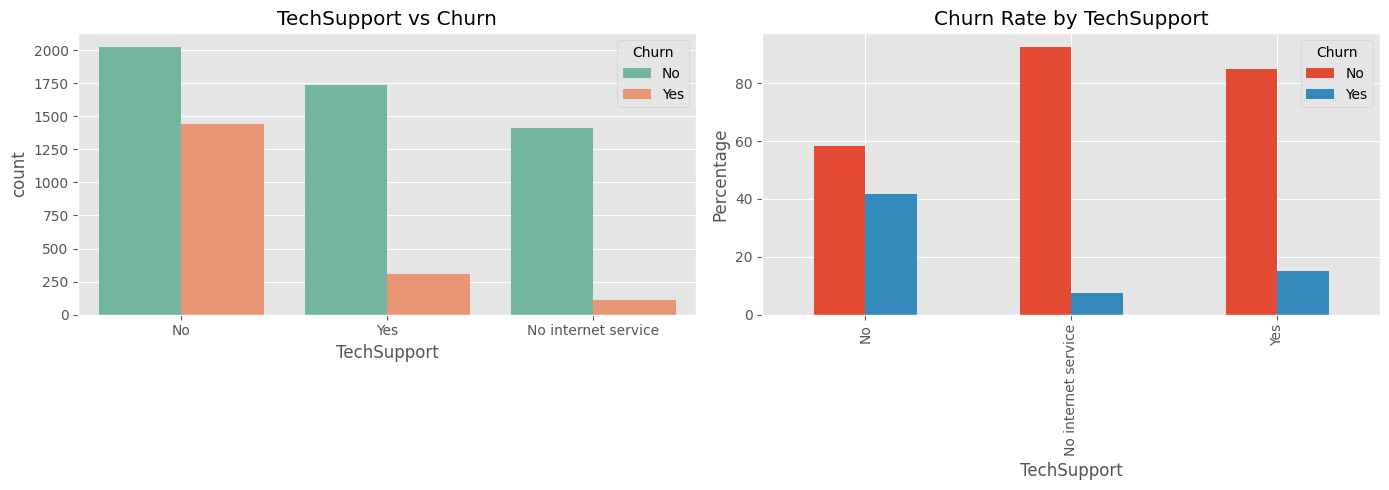


STREAMINGTV

Count Table


Churn,No,Yes,All
StreamingTV,,,
No,1868,942,2810
No internet service,1413,113,1526
Yes,1893,814,2707
All,5174,1869,7043



Churn Percentage


Churn,No,Yes
StreamingTV,,
No,66.48,33.52
No internet service,92.60,7.40
Yes,69.93,30.07


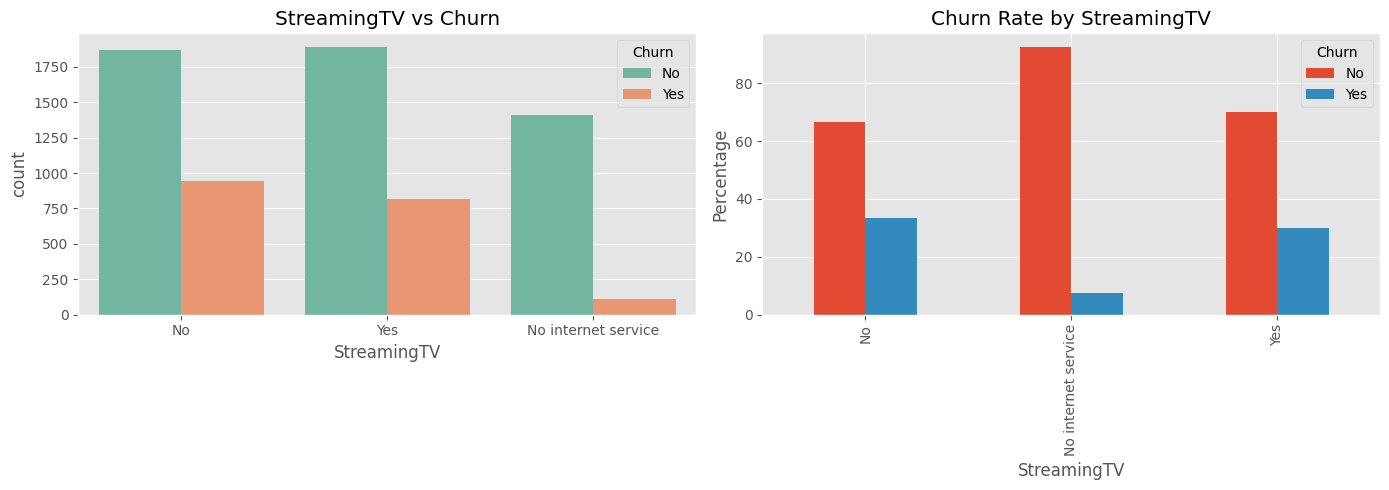


STREAMINGMOVIES

Count Table


Churn,No,Yes,All
StreamingMovies,,,
No,1847,938,2785
No internet service,1413,113,1526
Yes,1914,818,2732
All,5174,1869,7043



Churn Percentage


Churn,No,Yes
StreamingMovies,,
No,66.32,33.68
No internet service,92.60,7.40
Yes,70.06,29.94


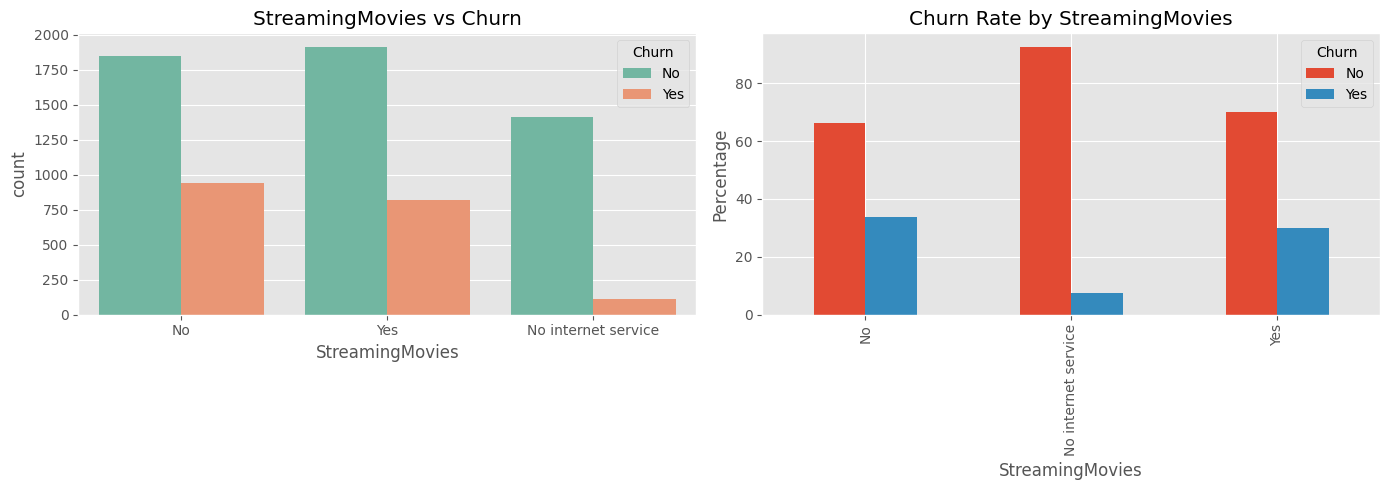

In [ ]:
services = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for feature in services:
    categorical_analysis(df, feature)

## SECTION 6: CONTRACTS & BILLING


CONTRACT

Count Table


Churn,No,Yes,All
Contract,,,
Month-to-month,2220,1655,3875
One year,1307,166,1473
Two year,1647,48,1695
All,5174,1869,7043



Churn Percentage


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


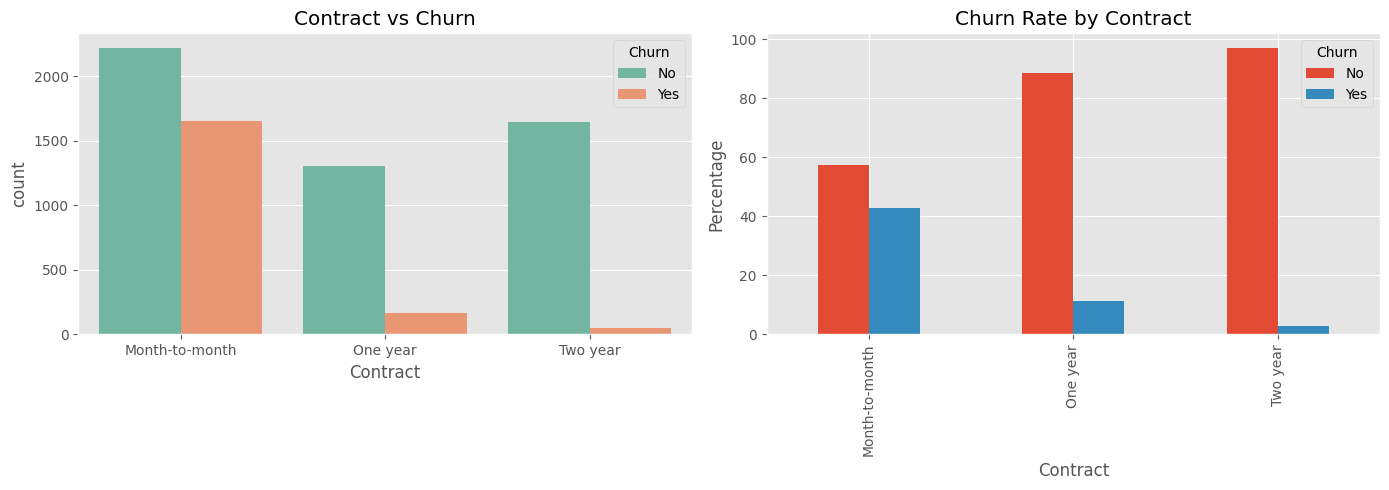


PAPERLESSBILLING

Count Table


Churn,No,Yes,All
PaperlessBilling,,,
No,2403,469,2872
Yes,2771,1400,4171
All,5174,1869,7043



Churn Percentage


Churn,No,Yes
PaperlessBilling,,
No,83.67,16.33
Yes,66.43,33.57


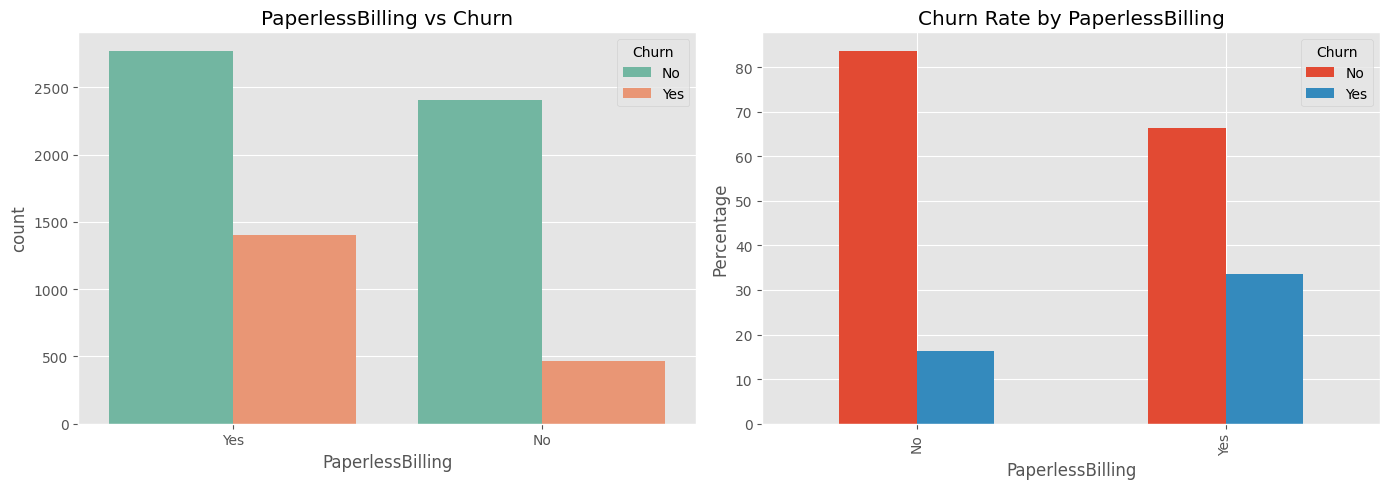


PAYMENTMETHOD

Count Table


Churn,No,Yes,All
PaymentMethod,,,
Bank transfer (automatic),1286,258,1544
Credit card (automatic),1290,232,1522
Electronic check,1294,1071,2365
Mailed check,1304,308,1612
All,5174,1869,7043



Churn Percentage


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


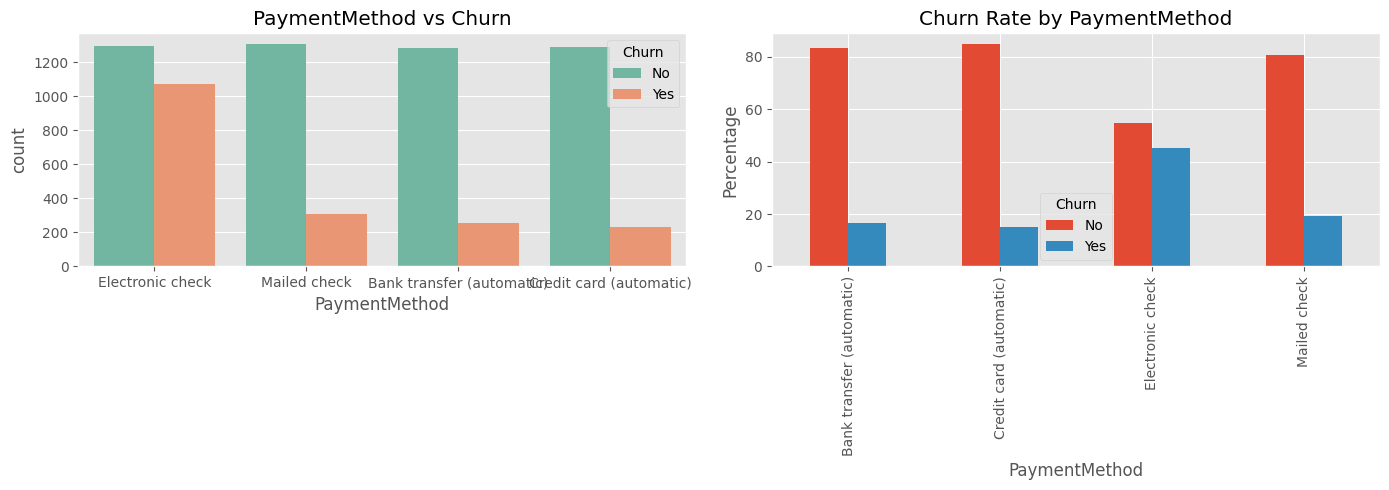

In [ ]:
billing = [
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

for feature in billing:
    categorical_analysis(df, feature)

## SECTION 7: CUSTOMER SUPPORT


NUMADMINTICKETS


Churn,No,Yes
numAdminTickets,,
0,72.94,27.06
1,78.92,21.08
2,74.49,25.51
3,74.43,25.57
4,79.39,20.61
5,73.47,26.53


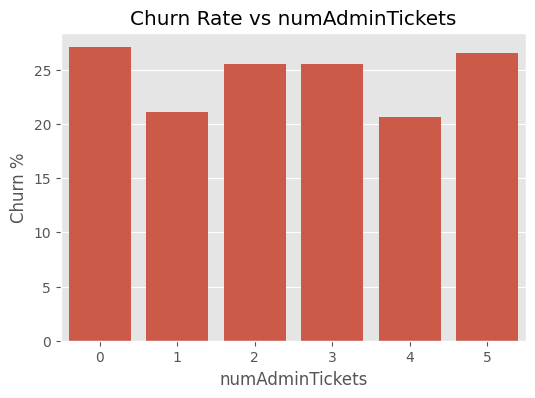


NUMTECHTICKETS


Churn,No,Yes
numTechTickets,,
0,80.31,19.69
1,34.38,65.62
2,37.31,62.69
3,33.11,66.89
4,30.83,69.17
5,25.00,75.00
6,18.06,81.94
7,3.45,96.55
8,0.00,100.00


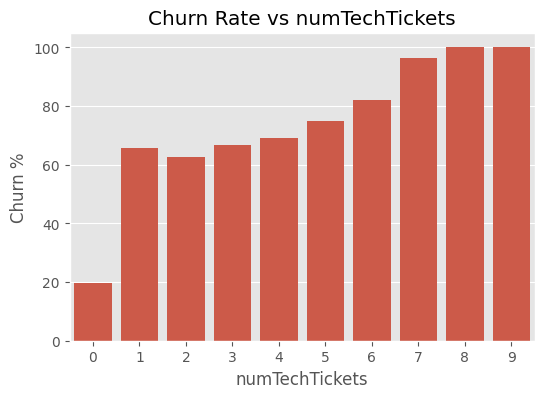

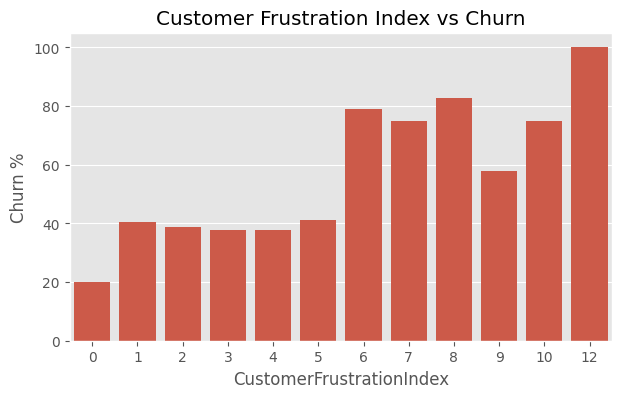

In [ ]:
support_analysis(df)

frustration_analysis(df)

## SECTION 8: FEATURE INTERACTIONS

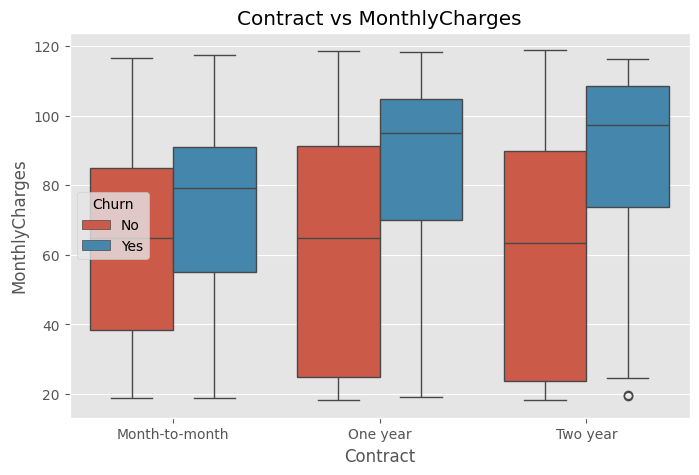

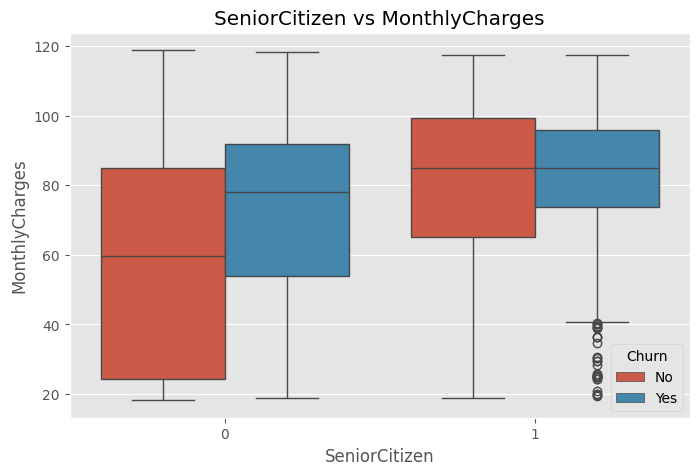

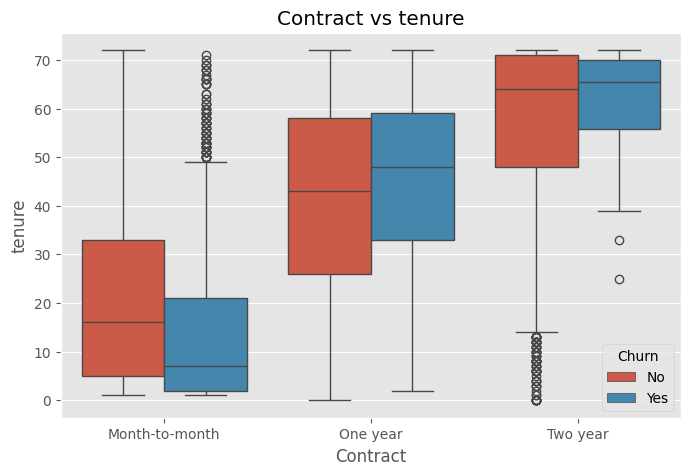

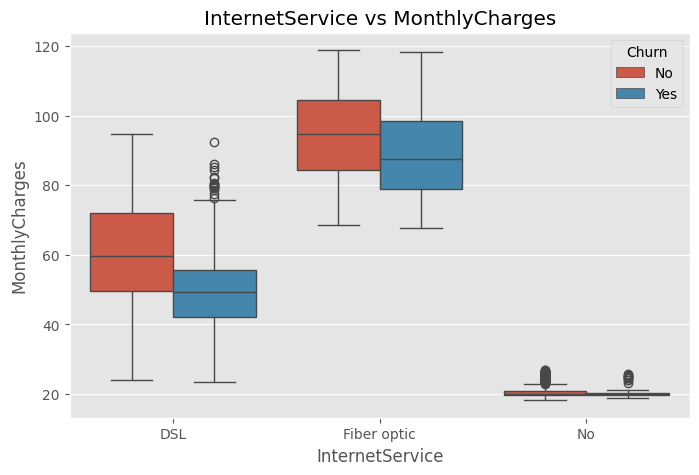

In [ ]:
interaction_analysis(df,"Contract","MonthlyCharges")

interaction_analysis(df,"SeniorCitizen","MonthlyCharges")

interaction_analysis(df,"Contract","tenure")

interaction_analysis(df,"InternetService","MonthlyCharges")

## CORRELATION ANALYSIS

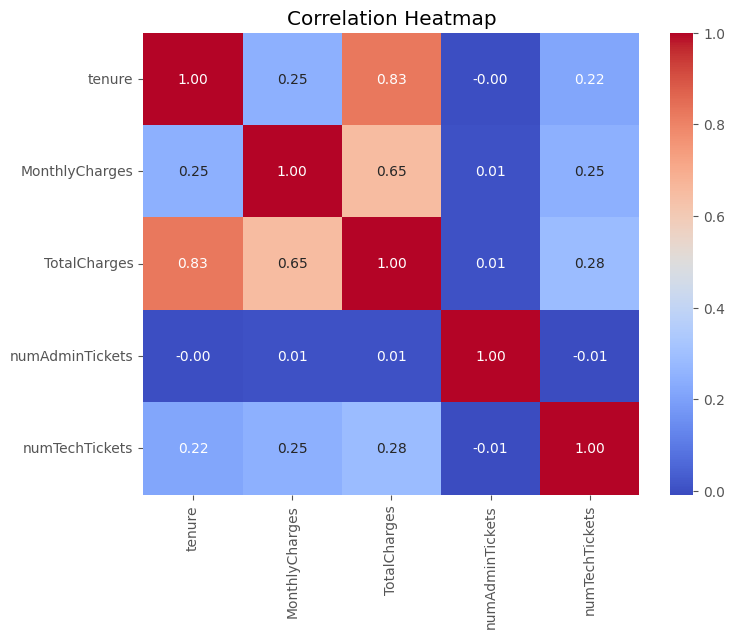

In [ ]:
correlation_analysis(df, numerical_cols)

#Insights after EDA
##EDA reveals that customer churn is primarily influenced by tenure, pricing, internet service type, contract type, value-added services, and technical support experience, while demographic factors such as gender have minimal impact.

# Feature Engineering
## Objective
Every engineered feature should answer a business problem or capture information that the raw data misses.

## List of features that is going to be generated:
CustomerFrustrationIndex

ServiceAdoptionScore

CustomerAgeGroup

MonthlyChargeCategory

LifetimeValueCategory

PaymentType

ContractCommitment

TicketSeverity

SupportPerMonth

AverageMonthlySpend

## Feature generation code

In [ ]:
df["CustomerFrustrationIndex"] = (
    df["numAdminTickets"] +
    df["numTechTickets"]
)

df["CustomerFrustrationIndex"].describe()

,CustomerFrustrationIndex
count,7043.000000
mean,0.935255
std,1.778667
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,12.000000


In [ ]:
df[["numAdminTickets",
    "numTechTickets",
    "CustomerFrustrationIndex"]].head()

,numAdminTickets,numTechTickets,CustomerFrustrationIndex
0,0,0,0
1,0,0,0
2,0,0,0
3,0,3,3
4,0,0,0


In [ ]:
service_cols = [
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["ServiceAdoptionScore"] = (
    df[service_cols]
    .apply(lambda x: x.eq("Yes"))
    .sum(axis=1)
)

df["ServiceAdoptionScore"].value_counts().sort_index()

,count
ServiceAdoptionScore,
0,1667
1,1158
2,957
3,978
4,933
5,722
6,420
7,208


In [ ]:
df[service_cols + ["ServiceAdoptionScore"]].head()

,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,ServiceAdoptionScore
0,No phone service,No,Yes,No,No,No,No,1
1,No,Yes,No,Yes,No,No,No,2
2,No,Yes,Yes,No,No,No,No,2
3,No phone service,Yes,No,Yes,Yes,No,No,3
4,No,No,No,No,No,No,No,0


In [ ]:
df["CustomerAgeGroup"] = pd.cut(
    df["tenure"],
    bins=[-1,12,36,72],
    labels=["New","Growing","Loyal"]
)

df["CustomerAgeGroup"].value_counts()

,count
CustomerAgeGroup,
Loyal,3001
New,2186
Growing,1856


In [ ]:
df["MonthlyChargeCategory"] = pd.qcut(
    df["MonthlyCharges"],
    q=3,
    labels=["Low","Medium","High"]
)

df["MonthlyChargeCategory"].value_counts()

,count
MonthlyChargeCategory,
Low,2351
High,2347
Medium,2345


In [ ]:
df["LifetimeValueCategory"] = pd.qcut(
    df["TotalCharges"],
    q=3,
    labels=["Low","Medium","High"]
)

df["LifetimeValueCategory"].value_counts()

,count
LifetimeValueCategory,
Low,2348
High,2348
Medium,2347


In [ ]:
df["PaymentType"] = np.where(
    df["PaymentMethod"].str.contains("automatic", case=False),
    "Automatic",
    "Manual"
)

df["PaymentType"].value_counts()

,count
PaymentType,
Manual,3977
Automatic,3066


In [ ]:
contract_map = {
    "Month-to-month":"Short",
    "One year":"Medium",
    "Two year":"Long"
}

df["ContractCommitment"] = df["Contract"].map(contract_map)

df["ContractCommitment"].value_counts()

,count
ContractCommitment,
Short,3875
Long,1695
Medium,1473


In [ ]:
df["TicketSeverity"] = pd.cut(
    df["CustomerFrustrationIndex"],
    bins=[-1,2,5,20],
    labels=["Low","Medium","High"]
)

df["TicketSeverity"].value_counts()

,count
TicketSeverity,
Low,5815
Medium,1043
High,185


In [ ]:
df["SupportPerMonth"] = (
    df["CustomerFrustrationIndex"] /
    (df["tenure"] + 1)
)

df["SupportPerMonth"].describe()

,SupportPerMonth
count,7043.000000
mean,0.068268
std,0.266960
min,0.000000
25%,0.000000
50%,0.000000
75%,0.040408
max,5.000000


In [ ]:
df["AverageMonthlySpend"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

df["AverageMonthlySpend"].describe()

,AverageMonthlySpend
count,7043.000000
mean,58.990789
std,30.579745
min,0.000000
25%,26.041493
50%,60.937879
75%,84.830742
max,118.969863


In [ ]:
new_features = [
    "CustomerFrustrationIndex",
    "ServiceAdoptionScore",
    "CustomerAgeGroup",
    "MonthlyChargeCategory",
    "LifetimeValueCategory",
    "PaymentType",
    "ContractCommitment",
    "TicketSeverity",
    "SupportPerMonth",
    "AverageMonthlySpend"
]

df[new_features].head()

,CustomerFrustrationIndex,ServiceAdoptionScore,CustomerAgeGroup,MonthlyChargeCategory,LifetimeValueCategory,PaymentType,ContractCommitment,TicketSeverity,SupportPerMonth,AverageMonthlySpend
0,0,1,New,Low,Low,Manual,Short,Low,0.000000,14.925000
1,0,2,Growing,Medium,Medium,Manual,Medium,Low,0.000000,53.985714
2,0,2,New,Medium,Low,Manual,Short,Low,0.000000,36.050000
3,3,3,Loyal,Low,Medium,Automatic,Medium,Medium,0.065217,40.016304
4,0,0,New,Medium,Low,Manual,Short,Low,0.000000,50.550000


#Feature Selection


In [ ]:
df_model = df.drop(columns=["customerID"])

print(df_model.shape)

(7043, 32)


In [ ]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7043, 31)
Target: (7043,)


In [ ]:
print("Numerical Features")
display(X.select_dtypes(include=["int64","float64"]).columns)

print("\nCategorical Features")
display(X.select_dtypes(include=["object","category"]).columns)

Numerical Features


Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'numAdminTickets', 'numTechTickets', 'CustomerFrustrationIndex',
       'ServiceAdoptionScore', 'SupportPerMonth', 'AverageMonthlySpend'],
      dtype='object')


Categorical Features


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'CustomerAgeGroup',
       'MonthlyChargeCategory', 'LifetimeValueCategory', 'PaymentType',
       'ContractCommitment', 'TicketSeverity'],
      dtype='object')

In [ ]:
X.isnull().sum().sort_values(ascending=False)

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
constant_features = [
    col for col in X.columns
    if X[col].nunique() == 1
]

print(constant_features)

[]


In [ ]:
df.to_csv("telecom_customer_churn_cleaned.csv", index=False)

In [ ]:
from google.colab import files

files.download("telecom_customer_churn_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Machine Learning
## Data Preprocessing
1. Train-Test Split
2. Encode Categorical Features
3. Scale Numerical Features (for comparison models)
4. Handle Class Imbalance (SMOTE)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (5634, 31)
Testing Features  : (1409, 31)
Training Labels   : (5634,)
Testing Labels    : (1409,)


In [ ]:
numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features:", len(numerical_cols))
print(numerical_cols)

print("\nCategorical Features:", len(categorical_cols))
print(categorical_cols)

Numerical Features: 10
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'numAdminTickets', 'numTechTickets', 'CustomerFrustrationIndex', 'ServiceAdoptionScore', 'SupportPerMonth', 'AverageMonthlySpend']

Categorical Features: 21
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'CustomerAgeGroup', 'MonthlyChargeCategory', 'LifetimeValueCategory', 'PaymentType', 'ContractCommitment', 'TicketSeverity']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [ ]:
X_train_encoded = preprocessor.fit_transform(X_train)

X_test_encoded = preprocessor.transform(X_test)

print("Encoded Training Shape :", X_train_encoded.shape)
print("Encoded Testing Shape  :", X_test_encoded.shape)

Encoded Training Shape : (5634, 68)
Encoded Testing Shape  : (1409, 68)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)

X_test_scaled = scaler.transform(X_test_encoded)

## Model Building
**Models to train**

1.Logistic Regression -	Baseline, simple and interpretable

2.Decision Tree -	First tree-based model

3.Random Forest-	Main model, expected best performer

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [109]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [110]:
results = []

for name, model in models.items():

    model.fit(X_train_balanced, y_train_balanced)

    y_pred = model.predict(X_test_encoded)
    y_prob = model.predict_proba(X_test_encoded)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label="Yes"),
        "Recall": recall_score(y_test, y_pred, pos_label="Yes"),
        "F1 Score": f1_score(y_test, y_pred, pos_label="Yes"),
        "ROC-AUC": roc_auc_score((y_test == "Yes").astype(int), y_prob)
    })

results_df = pd.DataFrame(results)
results_df.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.840312,0.649299,0.866310,0.742268,0.930409
2,Random Forest,0.836764,0.706897,0.657754,0.681440,0.911420
1,Decision Tree,0.814762,0.649077,0.657754,0.653386,0.764626


## Applying SMOTE for imbalanced dataset

In [111]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Scale first
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# Then apply SMOTE
smote = SMOTE(random_state=42)

X_train_scaled_balanced, y_train_scaled_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [112]:
X_train_scaled_balanced

array([[-0.99433624,  0.99433624,  0.96923413, ...,  0.25195569,
         0.27944017, -0.38983654],
       [-0.99433624,  0.99433624, -1.03174245, ..., -0.72131709,
         0.71176038,  0.41682134],
       [-0.99433624,  0.99433624, -1.03174245, ...,  0.25195569,
        -0.26096009, -0.55637416],
       ...,
       [ 0.70458398, -0.70458398, -1.03174245, ...,  0.32522055,
         0.17216888,  1.25347828],
       [ 1.00569602, -1.00569602,  0.96923413, ..., -0.72131709,
        -0.26096009, -0.34383041],
       [-0.99433624,  0.99433624,  0.96923413, ..., -1.20795348,
        -0.26096009, -0.78066999]])

In [113]:
X_test_scaled

array([[-0.99433624,  0.99433624, -1.03174245, ...,  2.19850125,
        -0.26096009,  1.8545684 ],
       [ 1.00569602, -1.00569602,  0.96923413, ...,  0.73859208,
         1.90064095,  1.36304882],
       [ 1.00569602, -1.00569602, -1.03174245, ...,  1.22522847,
        -0.26096009,  0.56327953],
       ...,
       [-0.99433624,  0.99433624,  0.96923413, ..., -1.20795348,
        -0.26096009, -1.42417087],
       [ 1.00569602, -1.00569602,  0.96923413, ..., -1.20795348,
        -0.26096009, -1.33069403],
       [ 1.00569602, -1.00569602, -1.03174245, ...,  1.22522847,
        -0.26096009,  0.37734819]])

## Hyperparameter Tuning

In [114]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# If using Option 1
y_train_binary = y_train_balanced.map({"No": 0, "Yes": 1})

scores = cross_val_score(
    RandomForestClassifier(random_state=42),
    X_train_balanced,
    y_train_binary,
    cv=5,
    scoring="f1"
)

print(scores)
print(scores.mean())

[0.75725407 0.81296421 0.94231868 0.93348493 0.93439817]
0.8760840133896005


In [115]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score

# Convert target to binary
y_train_binary = y_train_balanced.map({"No": 0, "Yes": 1})

# Hyperparameter search space
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

# F1 scorer
f1_scorer = make_scorer(f1_score)

# Base model
rf = RandomForestClassifier(random_state=42)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=30,
    scoring=f1_scorer,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train
_=random_search.fit(X_train_balanced, y_train_binary)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [116]:
print("Best Parameters:\n")
print(random_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(random_search.best_score_)

Best Parameters:

{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': False}

Best Cross Validation F1 Score:
0.8844760131127689


In [117]:
best_rf = random_search.best_estimator_

_=best_rf.fit(
    X_train_balanced,
    y_train_binary
)

In [ ]:
y_pred = best_rf.predict(X_test_encoded)
y_prob = best_rf.predict_proba(X_test_encoded)[:, 1]

y_test_binary = y_test.map({"No": 0, "Yes": 1})

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test_binary, y_pred))
print("Precision:", precision_score(y_test_binary, y_pred))
print("Recall   :", recall_score(y_test_binary, y_pred))
print("F1 Score :", f1_score(y_test_binary, y_pred))
print("ROC AUC  :", roc_auc_score(y_test_binary, y_prob))

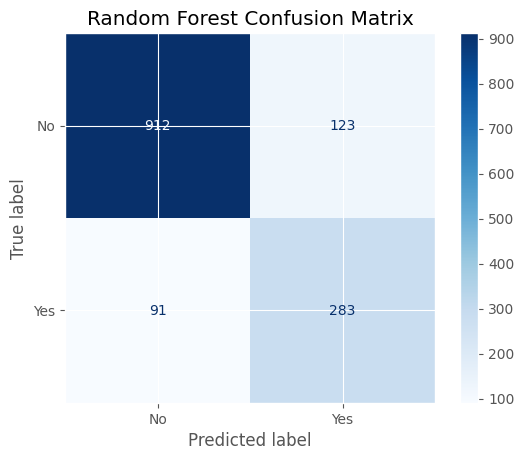

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_binary,
    y_pred,
    display_labels=["No", "Yes"],
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_binary,
        y_pred,
        target_names=["No", "Yes"]
    )
)

              precision    recall  f1-score   support

          No       0.91      0.88      0.89      1035
         Yes       0.70      0.76      0.73       374

    accuracy                           0.85      1409
   macro avg       0.80      0.82      0.81      1409
weighted avg       0.85      0.85      0.85      1409



## Feature Importance

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = (
    best_rf.feature_names_in_
    if hasattr(best_rf, "feature_names_in_")
    else preprocessor.get_feature_names_out()
)

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
63,remainder__numTechTickets,0.083897
54,cat__ContractCommitment_Short,0.078394
32,cat__Contract_Month-to-month,0.068068
14,cat__OnlineSecurity_No,0.057829
23,cat__TechSupport_No,0.050001
39,cat__PaymentMethod_Electronic check,0.048847
66,remainder__SupportPerMonth,0.038894
17,cat__OnlineBackup_No,0.038313
59,remainder__tenure,0.034755
61,remainder__TotalCharges,0.031343


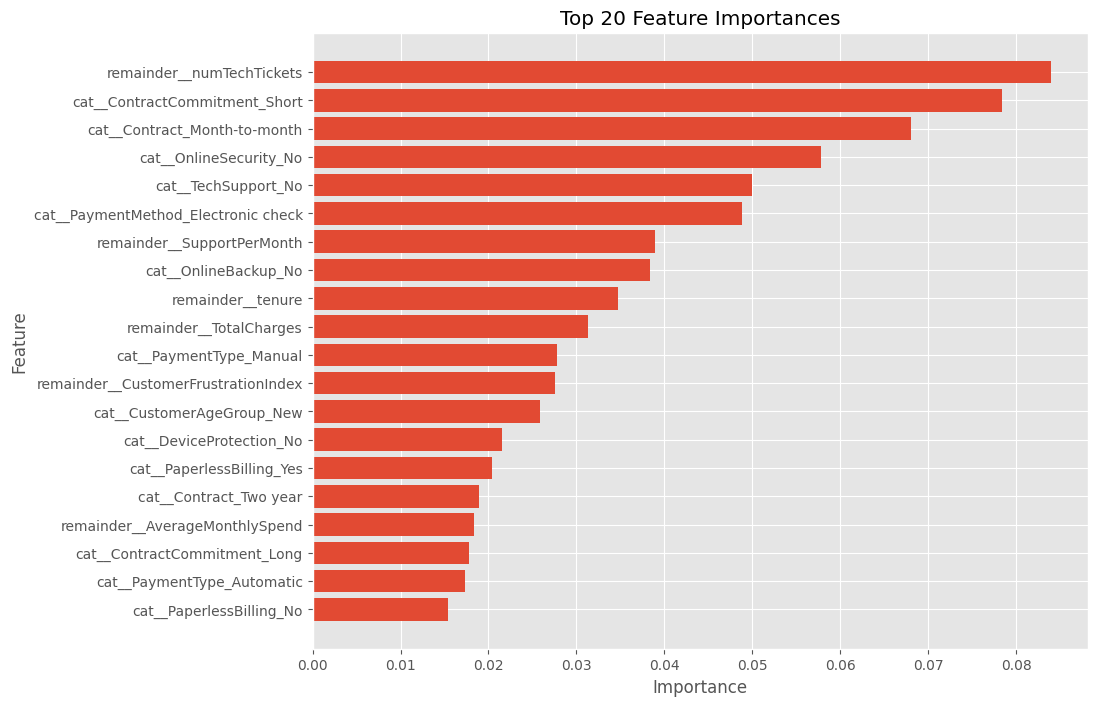

In [ ]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:20][::-1],
    importance["Importance"][:20][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances")
plt.show()

# SHAP Analysis

In [ ]:
!pip install shap -q

In [ ]:
import shap

explainer = shap.TreeExplainer(best_rf)

In [ ]:
shap_values = explainer.shap_values(X_test_encoded)

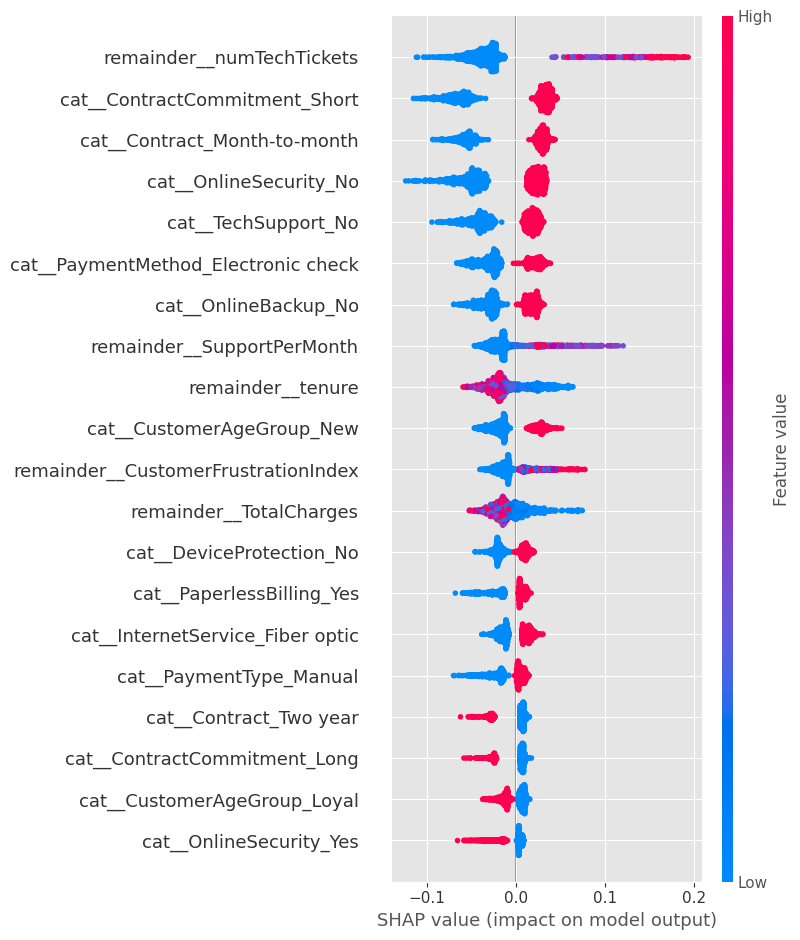

In [ ]:
shap.summary_plot(
    shap_values[:,:,1],
    X_test_encoded,
    feature_names=feature_names
)

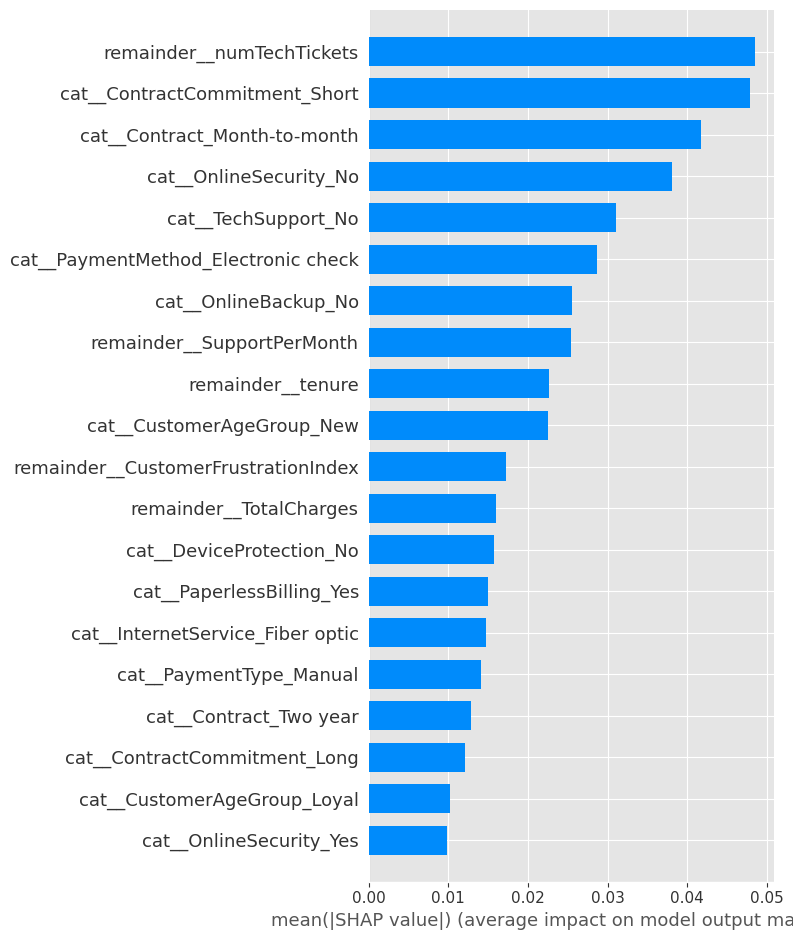

In [ ]:
shap.summary_plot(
    shap_values[:,:,1],
    X_test_encoded,
    feature_names=feature_names,
    plot_type="bar"
)

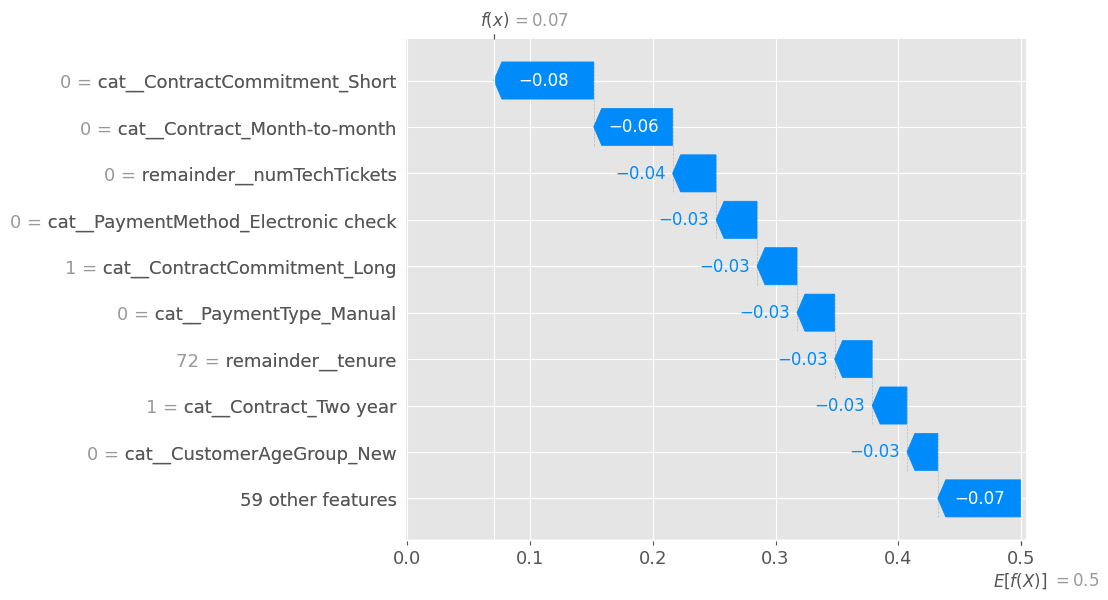

In [ ]:
customer = 15

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[customer,:,1],
        base_values=explainer.expected_value[1],
        data=X_test_encoded[customer],
        feature_names=feature_names
    )
)

# **Comparison Table ( Before vs After SMOTE )**
| **Metric** | **Baseline Random Forest (Before SMOTE & Tuning)** | **Final Random Forest (After SMOTE, Feature Engineering & Hyperparameter Tuning)** | **Change** |
| ---------- | :------------------------------------------------: | :--------------------------------------------------------------------------------: | :--------: |
| Accuracy   |                       0.8368                       |                                     **0.8481**                                     |   +1.13% |
| Precision  |                       0.7069                       |                                     **0.6970**                                     |   -1.39% |
| Recall     |                       0.6578                       |                                     **0.7567**                                     |   +9.89% |
| F1 Score   |                       0.6814                       |                                     **0.7256**                                     |   +4.42% |
| ROC-AUC    |                       0.9114                       |                                     **0.9155**                                     |   +0.40% |


# **Conclusion**
1.Accuracy improved slightly, indicating better overall classification.

2.Recall improved significantly (Approx.10%), enabling the model to identify substantially more customers likely to churn.

3.F1-score increased from 0.681 to 0.726, demonstrating a better balance between precision and recall.

4.ROC-AUC improved to 0.915, indicating excellent discrimination between churning and non-churning customers.

5.Although Precision decreased marginally, this is an acceptable trade-off in churn prediction since identifying more at-risk customers is generally more valuable than minimizing false positives.

#**BUSINESS RECOMMENDATIONS**

1. Prioritize customers with high Customer Frustration Index.
2. Reduce technical support resolution time.
3. Encourage customers to move from month-to-month to long-term contracts.
4. Promote Online Security and Tech Support add-ons.
5. Target high Monthly Charge customers with personalized retention offers.
6. Monitor new customers during their first year of service.
7. Encourage automatic payment methods.
8. Build an early-warning churn dashboard using the trained model.

